# SARS-CoV-2 CT Demo

In [1]:
from pathlib import Path
import sys

cwd = Path.cwd().resolve()
repo = cwd.parent if cwd.name == "notebooks" else cwd
if repo.name == "tcda_uq":
    sys.path.insert(0, str(repo.parent))
elif (repo / "tcda_uq").exists():
    sys.path.insert(0, str(repo))

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=PendingDeprecationWarning)

The real SARS-CoV-2 CT loader needs the optional ``[data]`` extra and
local dataset files. This executable tutorial uses ``TCDA_UQ_SARS_ROOT``
when available, otherwise it falls back to tiny synthetic CT-like
images so the image-to-silhouette and causal-UQ code path still runs.

In [2]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression

from tcda_uq import evaluate_coverage, tate_band
from tcda_uq.datasets.sarscov2 import images_to_silhouettes, load_ct_images, make_sarscov2_causal
from tcda_uq.estimators import cross_fit

In [3]:
root = os.environ.get("TCDA_UQ_SARS_ROOT")
if root:
    infected, noninfected = load_ct_images(root)
    infected = infected[:12]
    noninfected = noninfected[:12]
    source = "local SARS-CoV-2 CT files"
else:
    rng = np.random.default_rng(30)
    grid = np.linspace(-1.0, 1.0, 18)
    xx, yy = np.meshgrid(grid, grid)

    def blob(offset, scale):
        base = np.exp(-((xx - offset) ** 2 + yy**2) / scale)
        return np.clip(base + 0.08 * rng.normal(size=base.shape), 0.0, 1.0)

    infected = [blob(-0.25, 0.22) for _ in range(14)]
    noninfected = [blob(0.25, 0.35) for _ in range(14)]
    source = "synthetic CT-like images"

phi_inf = images_to_silhouettes(infected, resolution=24, workers=1)
phi_non = images_to_silhouettes(noninfected, resolution=24, workers=1)
causal = make_sarscov2_causal(phi_inf, phi_non, n=20, p=0.70, rng=31)

In [4]:
rng = np.random.default_rng(32)
po = causal["potential_outcomes"]
n = po.shape[0]
X = rng.normal(size=(n, 2))
A = np.array([0, 1] * (n // 2))
rng.shuffle(A)
phi = po[np.arange(n), A]
tseq = np.linspace(0.0, 1.0, po.shape[-1])

fit = cross_fit(
    (phi, A, X),
    tseq,
    n_basis=4,
    n_splits=2,
    random_state=33,
    propensity_estimator=LogisticRegression(max_iter=500),
)
band = tate_band(fit, method="mbb", d=0, alpha=0.10, n_boot=80, rng=34)
truth = causal["true_effect"][0]

pd.DataFrame(
    [
        {
            "source": source,
            "n_images_used": len(infected) + len(noninfected),
            "coverage_against_constructed_truth": evaluate_coverage(band, truth).coverage,
            "mean_width": band.mean_width(),
        }
    ]
)

,source,n_images_used,coverage_against_constructed_truth,mean_width
0,synthetic CT-like images,28,1.0,0.004925


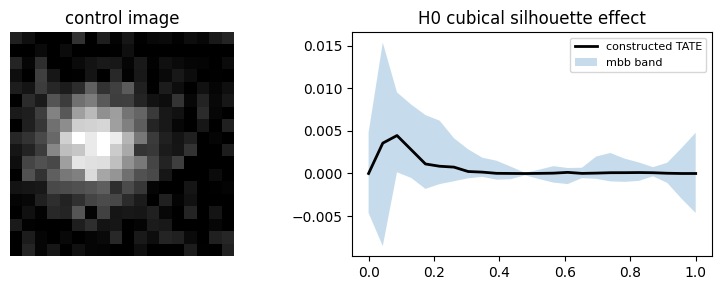

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(8, 3))
ax[0].imshow(infected[0], cmap="gray")
ax[0].set_title("control image")
ax[0].axis("off")
ax[1].plot(tseq, truth, color="black", lw=2, label="constructed TATE")
ax[1].fill_between(tseq, band.lower, band.upper, alpha=0.25, label="mbb band")
ax[1].legend(loc="best", fontsize=8)
ax[1].set_title("H0 cubical silhouette effect")
fig.tight_layout()